# k-Anonymity Impact on Model Performance
This notebook analyzes how different models behave under various levels of k-anonymity on the Banking dataset. It explores:
- Accuracy vs. k, LM, and MD
- F1-Score vs. k, LM, and MD
- Comparative robustness of models under increasing anonymity

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Load the dataset
df = pd.read_csv("../results/banking_model_results_1.csv")
df.head()

,k,model,LM,MD,accuracy,f1_0,f1_1,macro_avg_f1,macro_avg_precision,macro_avg_recall,precision_0,precision_1,recall_0,recall_1,weighted_avg_f1,weighted_avg_precision,weighted_avg_recall
0,1,logistic,0.0000,0,0.721331,0.823998,0.331210,0.577604,0.580864,0.664276,0.931470,0.230258,0.738760,0.589792,0.766343,0.849431,0.721331
1,2,logistic,63042.4733,359903,0.671901,0.785668,0.300731,0.543199,0.564309,0.642026,0.928303,0.200314,0.681027,0.603025,0.728932,0.843131,0.671901
2,4,logistic,88947.0893,467508,0.656419,0.772797,0.295625,0.534211,0.561550,0.638999,0.928647,0.194453,0.661741,0.616257,0.716970,0.842749,0.656419
3,8,logistic,100511.1981,533745,0.639058,0.757756,0.292281,0.525018,0.559844,0.638187,0.930042,0.189645,0.639324,0.637051,0.703297,0.843418,0.639058
4,16,logistic,92905.6236,544369,0.568838,0.696599,0.255205,0.475902,0.539888,0.595965,0.919852,0.159923,0.560551,0.631380,0.644958,0.830943,0.568838


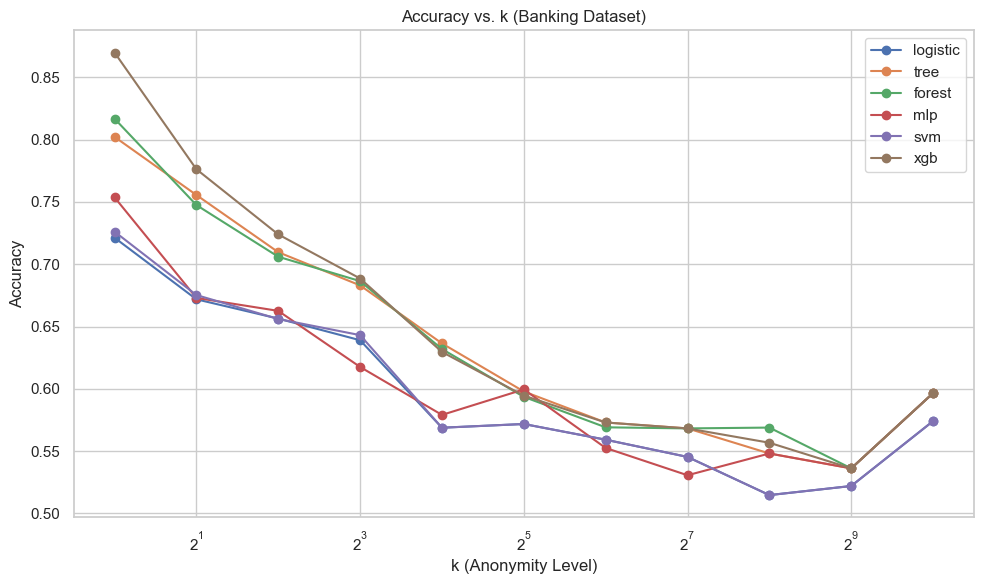

In [7]:
# Accuracy vs. k (log scale)
plt.figure(figsize=(10, 6))
for model in df['model'].unique():
    subset = df[df['model'] == model]
    plt.plot(subset['k'], subset['accuracy'], marker='o', label=model)
plt.xscale('log', base=2)
plt.title('Accuracy vs. k (Banking Dataset)')
plt.xlabel('k (Anonymity Level)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

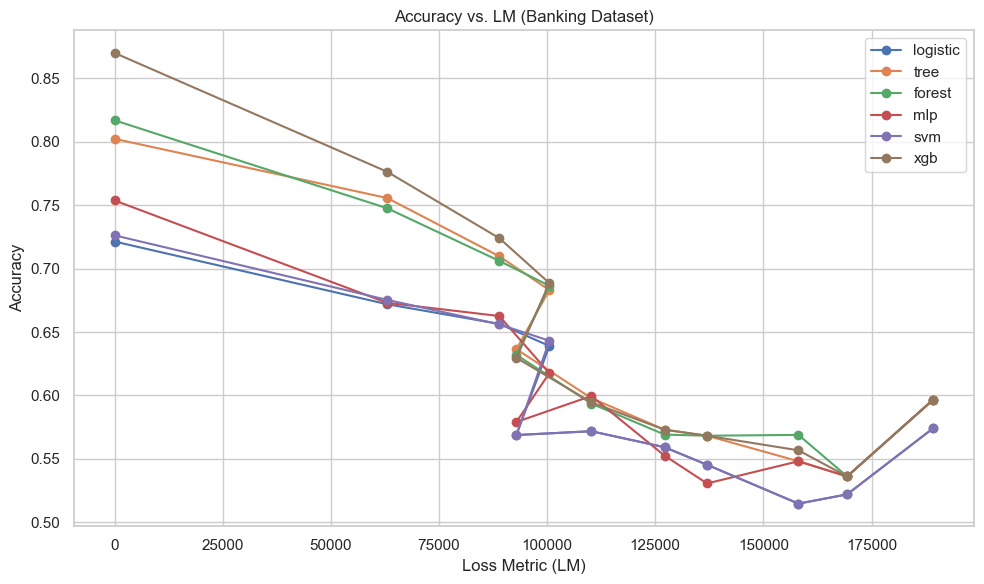

In [8]:
# Accuracy vs. LM
plt.figure(figsize=(10, 6))
for model in df['model'].unique():
    subset = df[df['model'] == model]
    plt.plot(subset['LM'], subset['accuracy'], marker='o', label=model)
plt.title('Accuracy vs. LM (Banking Dataset)')
plt.xlabel('Loss Metric (LM)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

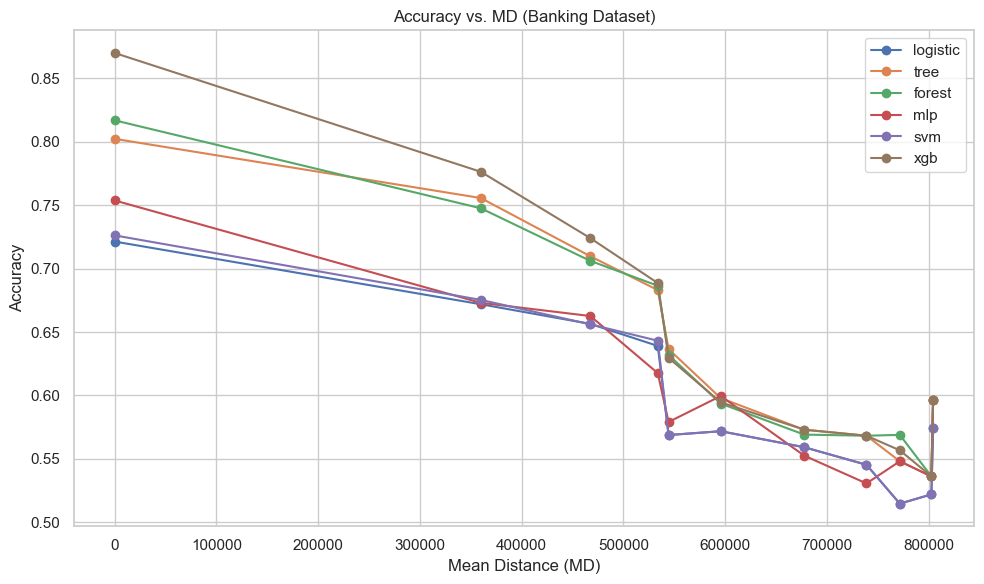

In [9]:
# Accuracy vs. MD
plt.figure(figsize=(10, 6))
for model in df['model'].unique():
    subset = df[df['model'] == model]
    plt.plot(subset['MD'], subset['accuracy'], marker='o', label=model)
plt.title('Accuracy vs. MD (Banking Dataset)')
plt.xlabel('Mean Distance (MD)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## F1-Score vs. k, LM, and MD

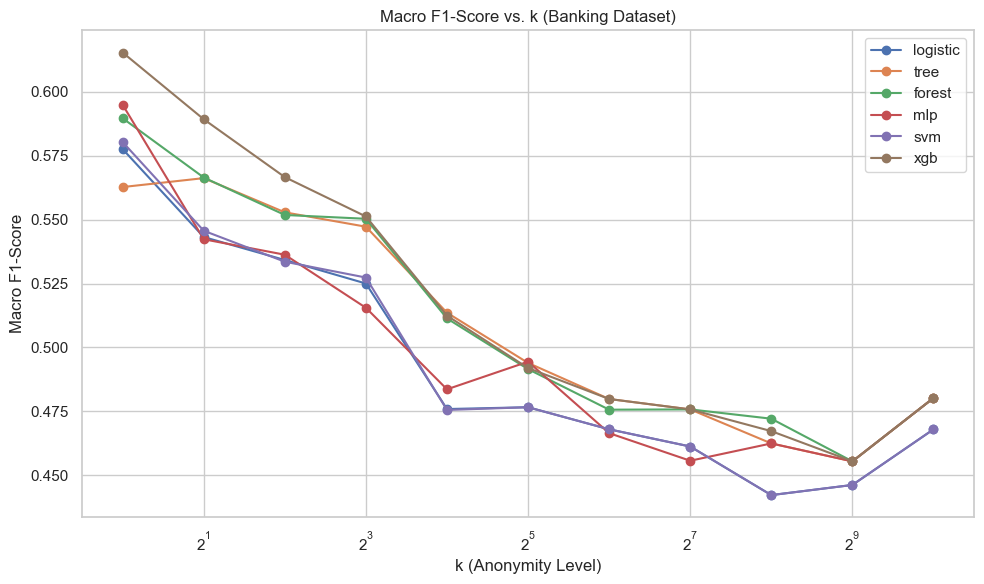

In [10]:
# Macro F1-Score vs. k
plt.figure(figsize=(10, 6))
for model in df['model'].unique():
    subset = df[df['model'] == model]
    plt.plot(subset['k'], subset['macro_avg_f1'], marker='o', label=model)
plt.xscale('log', base=2)
plt.title('Macro F1-Score vs. k (Banking Dataset)')
plt.xlabel('k (Anonymity Level)')
plt.ylabel('Macro F1-Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

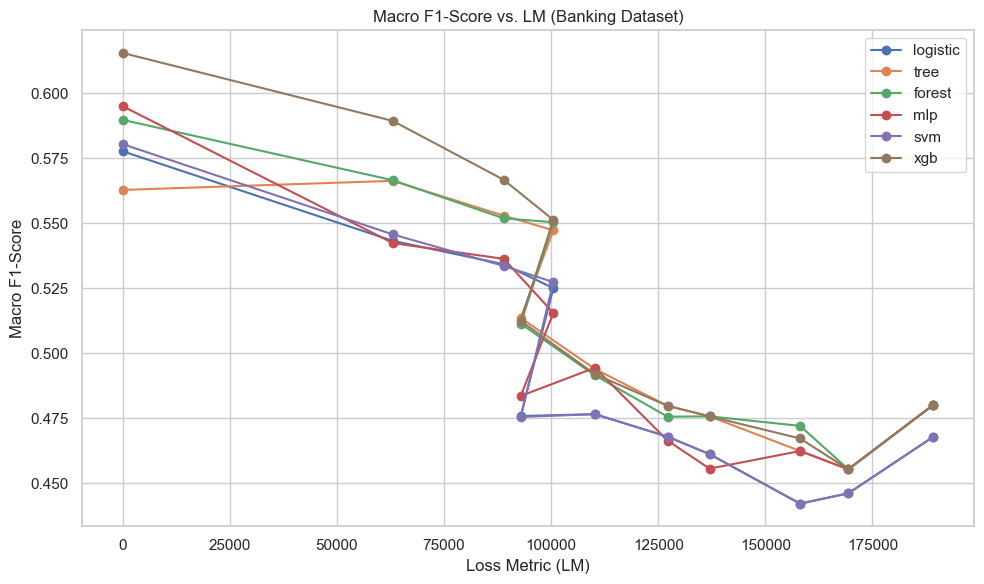

In [11]:
# Macro F1-Score vs. LM
plt.figure(figsize=(10, 6))
for model in df['model'].unique():
    subset = df[df['model'] == model]
    plt.plot(subset['LM'], subset['macro_avg_f1'], marker='o', label=model)
plt.title('Macro F1-Score vs. LM (Banking Dataset)')
plt.xlabel('Loss Metric (LM)')
plt.ylabel('Macro F1-Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

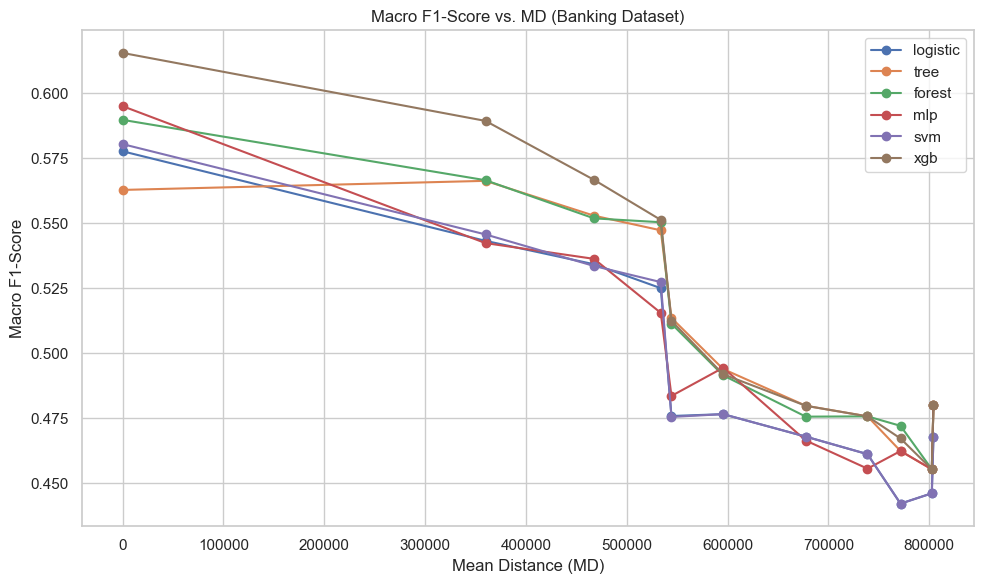

In [12]:
# Macro F1-Score vs. MD
plt.figure(figsize=(10, 6))
for model in df['model'].unique():
    subset = df[df['model'] == model]
    plt.plot(subset['MD'], subset['macro_avg_f1'], marker='o', label=model)
plt.title('Macro F1-Score vs. MD (Banking Dataset)')
plt.xlabel('Mean Distance (MD)')
plt.ylabel('Macro F1-Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Model Robustness Comparison

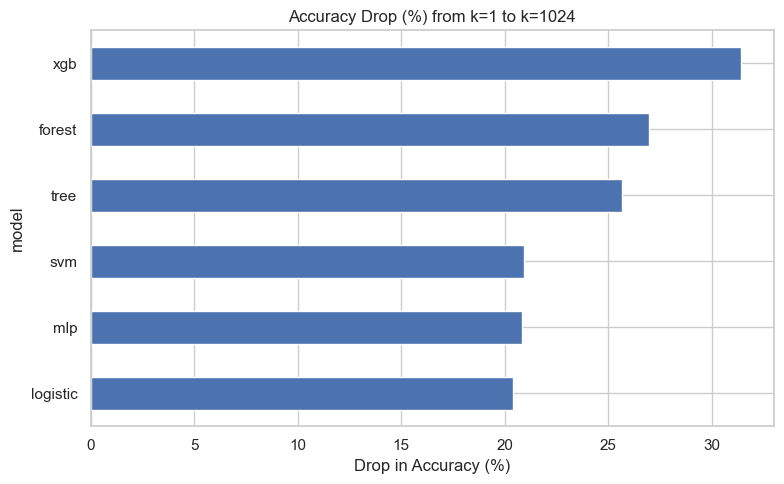

In [13]:
# Robustness analysis: accuracy decline rate from k=1 to k=1024
robustness = df[df['k'] == 1][['model', 'accuracy']].set_index('model')
robustness.columns = ['acc_k1']
acc_k1024 = df[df['k'] == 1024][['model', 'accuracy']].set_index('model')
acc_k1024.columns = ['acc_k1024']
robustness = robustness.join(acc_k1024)
robustness['drop (%)'] = (robustness['acc_k1'] - robustness['acc_k1024']) / robustness['acc_k1'] * 100
robustness.sort_values('drop (%)', inplace=True)
robustness.plot(kind='barh', y='drop (%)', legend=False, figsize=(8, 5), title='Accuracy Drop (%) from k=1 to k=1024')
plt.xlabel('Drop in Accuracy (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

## Load and Analyze Adult Dataset

In [14]:
df_adult = pd.read_csv("adult_model_results_1.csv")
df_adult.head()

FileNotFoundError: [Errno 2] No such file or directory: 'adult_model_results_1.csv'

In [ ]:
# Accuracy vs. k (Adult Dataset)
plt.figure(figsize=(10, 6))
for model in df_adult['model'].unique():
    subset = df_adult[df_adult['model'] == model]
    plt.plot(subset['k'], subset['accuracy'], marker='o', label=model)
plt.xscale('log', base=2)
plt.title('Accuracy vs. k (Adult Dataset)')
plt.xlabel('k (Anonymity Level)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()